In [1]:
import sys
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import yfinance as yf
import seaborn as sns
import numpy as np
import polars as pl

## RQ5: E10 - Diesel Price comparison and frquency of anomalies (Diesel price = E10 price//Diesel price > E10 price)

In [2]:
# Pfade
anomalies_path = Path(r"C:\Users\Marvin\Dokumente\Bildung\Uni\dsprojekt\tankerkoenig-data\anomalies")
parquet_base = Path(r"C:\Users\Marvin\Dokumente\Bildung\Uni\dsprojekt\tankerkoenig-data\prices_parquet")

# Lade alle verfügbaren Anomalie-Dateien
anomaly_files = sorted(anomalies_path.glob("*_all_anomalies.parquet"))

print(f"Gefundene Anomalie-Dateien: {len(anomaly_files)}")
for f in anomaly_files:
    print(f"  - {f.name}")


Gefundene Anomalie-Dateien: 13
  - 2014_all_anomalies.parquet
  - 2015_all_anomalies.parquet
  - 2016_all_anomalies.parquet
  - 2017_all_anomalies.parquet
  - 2018_all_anomalies.parquet
  - 2019_all_anomalies.parquet
  - 2020_all_anomalies.parquet
  - 2021_all_anomalies.parquet
  - 2022_all_anomalies.parquet
  - 2023_all_anomalies.parquet
  - 2024_all_anomalies.parquet
  - 2025_all_anomalies.parquet
  - 2026_all_anomalies.parquet


In [12]:
# Define the range of years you want to analyze
start_year = 2020
end_year = 2027

# Combine anomalies from how many years you want to see
dfs = []
for year in range(start_year, end_year): 
    year_file = anomalies_path / f"{year}_all_anomalies.parquet"
    if year_file.exists():
        try:
            df = pl.read_parquet(year_file)
            # Convert date to datetime (only date part, ignore time and timezone)
            df = df.with_columns(
                pl.col("date")
                .str.slice(0, 10)  # Only take YYYY-MM-DD
                .str.to_date()
                .alias("date_parsed")
            )
            dfs.append(df)
            print(f"{year} loaded ({df.height:,} anomalies)")
        except Exception as e:
            print(f"X {year} error: {e}")


combined = pl.concat(dfs)
combined = combined.with_columns(
    year=pl.col("date_parsed").dt.year(),
    month=pl.col("date_parsed").dt.month(),
    week=pl.col("date_parsed").dt.week()
)
print(f"\nTotal Anomalies: {combined.height:,} from {start_year}-{end_year-1}")


2020 loaded (69,399 anomalies)
2021 loaded (128,843 anomalies)
2022 loaded (52,323,353 anomalies)
2023 loaded (18,748,424 anomalies)
2024 loaded (4,690,880 anomalies)
2025 loaded (3,133,653 anomalies)
2026 loaded (2,055,590 anomalies)

Total Anomalies: 81,150,142 from 2020-2026


## E10-Diesel Anomalies per Month (for yearss loaded)

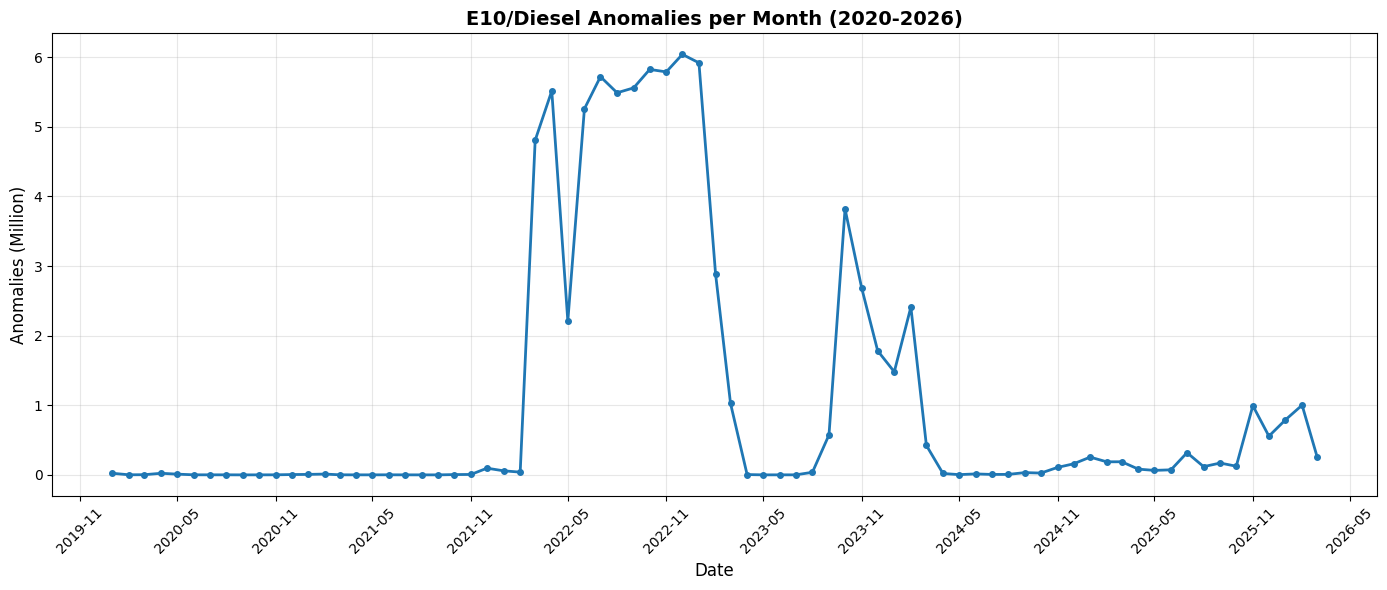

In [14]:
fig, ax = plt.subplots(figsize=(14, 6))

anomalies_per_month = combined.group_by(["year", "month"]).agg(pl.len().alias("count")).sort(["year", "month"])
anomalies_df = anomalies_per_month.to_pandas()
anomalies_df["date"] = pd.to_datetime(anomalies_df[["year", "month"]].assign(day=1))

ax.plot(anomalies_df["date"], anomalies_df["count"]/1_000_000, marker="o", linewidth=2, markersize=4)
ax.set_title(f"E10/Diesel Anomalies per Month ({start_year}-{end_year-1})", fontsize=14, fontweight="bold")
ax.set_xlabel("Date", fontsize=12)
ax.set_ylabel("Anomalies (Million)", fontsize=12)
ax.grid(True, alpha=0.3)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


## Total Anomalies per year

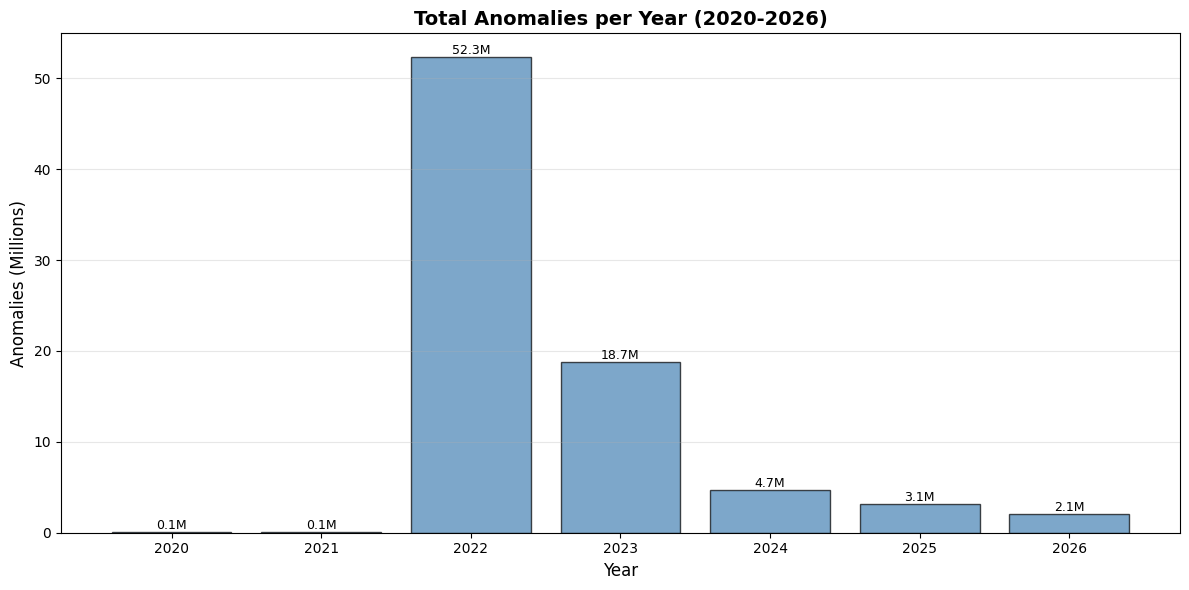

In [ ]:
# Anomalies per year
fig, ax = plt.subplots(figsize=(12, 6))

anomalies_per_year = combined.group_by("year").agg(pl.len().alias("count")).sort("year")
year_data = anomalies_per_year.to_pandas()

bars = ax.bar(year_data["year"], year_data["count"]/1_000_000, color="steelblue", alpha=0.7, edgecolor="black")
ax.set_title(f"Total Anomalies per Year ({start_year}-{end_year-1})", fontsize=14, fontweight="bold")
ax.set_xlabel("Year", fontsize=12)
ax.set_ylabel("Anomalies (Millions)", fontsize=12)
ax.grid(True, alpha=0.3, axis="y")

for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f"{height:.1f}M",
            ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()


## Distribution of Price anomalies by hour of day for any year

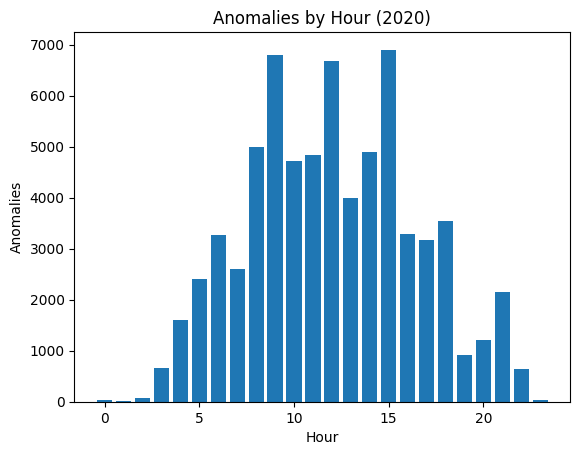

In [24]:
year = 2020
year_file = anomalies_path / f"{year}_all_anomalies.parquet"

df = (
    pl.scan_parquet(year_file)
    .select("date")
    .with_columns(
        pl.col("date")
        .str.replace(r"([+-]\d{2})$", r"$1:00")   # ChatGPT fix timezone format
        .str.strptime(pl.Datetime, "%Y-%m-%d %H:%M:%S%z")
        .dt.hour()
        .alias("hour")
    )
    .group_by("hour")
    .len()
    .sort("hour")
    .collect()
)

plt.bar(df["hour"], df["len"])
plt.xlabel("Hour")
plt.ylabel("Anomalies")
plt.title(f"Anomalies by Hour ({year})")
plt.show()

## Top 15 Gas Stations with most Anomalies between 2020 and 2025

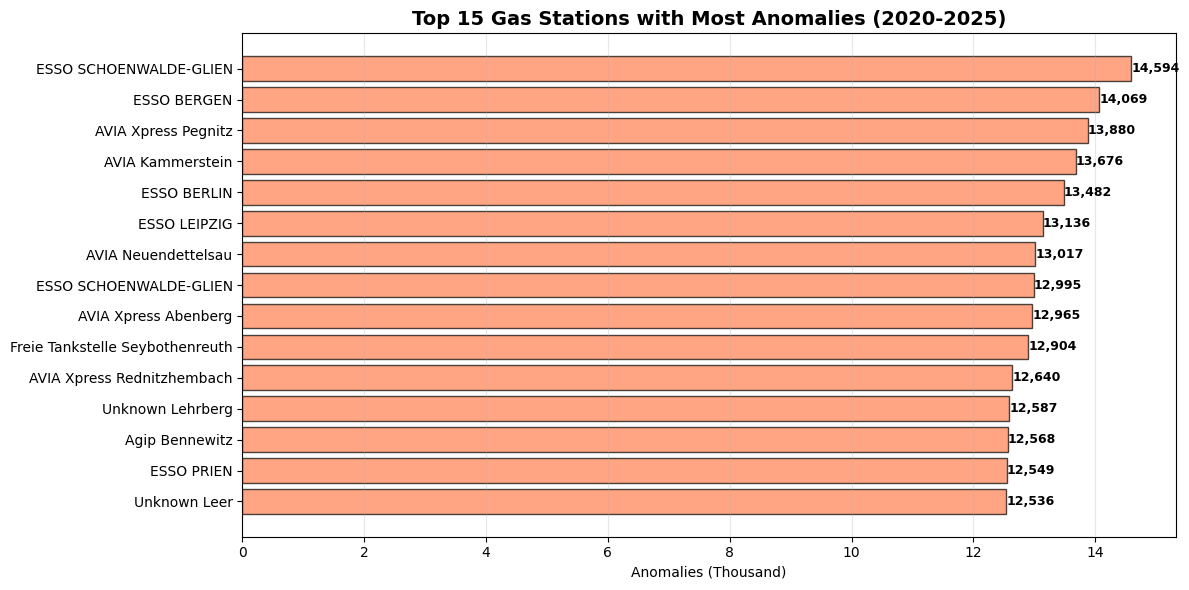


Top 15 Gas Stations by Anomalies:
1. ESSO (03697a19-4dec-4562-9264-bb8cd4d19fb2): 14,594 anomalies
2. ESSO (8dd39ed5-f22d-4d82-b24b-ad0261bbfd37): 14,069 anomalies
3. AVIA Xpress (80f05a47-a044-4cd0-b176-7a2bd097b26d): 13,880 anomalies
4. AVIA (1605f19f-a8b6-4445-82a4-8bbfea0f9f5e): 13,676 anomalies
5. ESSO (5ffe1e13-ef40-4695-aeb2-4612d58fac17): 13,482 anomalies
6. ESSO (4b57ad4b-8b70-45fc-869f-e613a6294ce9): 13,136 anomalies
7. AVIA (bce4b7c7-5f26-45bd-9906-c83388b24631): 13,017 anomalies
8. ESSO (04f824bf-28da-4b20-83ea-f0152598fae2): 12,995 anomalies
9. AVIA Xpress (e698a272-5859-4df4-9485-0d0707355581): 12,965 anomalies
10. Freie Tankstelle (43009ad1-6497-4250-9ab4-7108bbc3ff63): 12,904 anomalies
11. AVIA Xpress (01e1ea53-cd6f-4bbd-b750-c8e9b61902b1): 12,640 anomalies
12. nan (7753b618-ee54-4151-b535-cb29b4694a06): 12,587 anomalies
13. Agip (19d0bf4c-852e-4296-8a5f-be373894a1ac): 12,568 anomalies
14. ESSO (982cbdad-cc37-4189-a17c-0af9388ab9b1): 12,549 anomalies
15. nan (fd172e38-

In [ ]:
stations_csv = Path(r"C:\Users\Marvin\Dokumente\Bildung\Uni\dsprojekt\tankerkoenig-data\stations\stations.csv")
stations_parquet = Path("stations.parquet")

if stations_parquet.exists():
    stations = pl.read_parquet(stations_parquet)
else:
    stations = (
        pl.scan_csv(stations_csv)
        .select(["uuid", "brand", "city"])
        .collect()
    )
    stations.write_parquet(stations_parquet)

top_stations = (
    combined
    .group_by("station_uuid")
    .agg(pl.len().alias("count"))
    .sort("count", descending=True)
    .head(15)
)

# Join
top_stations = top_stations.join(
    stations,
    left_on="station_uuid",
    right_on="uuid",
    how="left"
)

top_stations = top_stations.with_columns(
    (pl.col("brand").fill_null("Unknown") + " " + pl.col("city").fill_null(""))
    .alias("label")
)

station_data = top_stations.to_pandas()

#Plot

fig, ax = plt.subplots(figsize=(12,6))

bars = ax.barh(
    range(len(station_data)),
    station_data["count"]/1000,
    color="coral",
    alpha=0.7,
    edgecolor="black"
)

ax.set_yticks(range(len(station_data)))
ax.set_yticklabels(station_data["label"])

ax.set_title(
    f"Top 15 Gas Stations with Most Anomalies ({start_year}-{end_year-1})",
    fontsize=14,
    fontweight="bold"
)

ax.set_xlabel("Anomalies (Thousand)")
ax.invert_yaxis()
ax.grid(True, alpha=0.3, axis="x")

for bar in bars:
    width = bar.get_width()
    ax.text(
        width,
        bar.get_y() + bar.get_height()/2,
        f"{int(width*1000):,}",
        ha="left",
        va="center",
        fontsize=9,
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

print("\nTop 15 Gas Stations by Anomalies:")
for idx, (_, row) in enumerate(station_data.iterrows(), 1):
    print(f"{idx}. {row['brand']} ({row['station_uuid']}): {int(row['count']):,} anomalies")

In [ ]:
file = Path(r"D:\Tankdaten\anomalies\price_diff_2022.parquet")

df = pl.read_parquet(file)

# Datum sicherstellen
df = df.with_columns(
    pl.col("date").str.strptime(pl.Datetime, strict=False)
)

# nach Datum sortieren
df = df.sort("date")

plt.figure(figsize=(12,6))
plt.scatter(df["date"], df["price_diff"], s=3)

plt.title("Diesel - E10 Price Difference (2022)")
plt.xlabel("Date")
plt.ylabel("Price Difference (€)")
plt.show()